<p style ="text-align:center">
    <img src="https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# Liga Data Science
## Prof. Eduardo Pécora

# Regressão Linear
Tempo estimado: **90** minutos

-----


# Predição de Custos em Saúde

# 1. Problema de Negócio
Uma operadora de plano de saúde deseja prever o custo anual de seus beneficiários com base em características demográficas e comportamentais.

Pergunta:

Quais fatores mais impactam o custo médico?

## Objetivos

Após completar esta aula, você será capaz de:

* Aplicar o fluxo completo de regressão linear a um problema real de negócio
* Codificar variáveis categóricas evitando a armadilha da variável dummy
* Interpretar os coeficientes de um modelo de regressão múltipla
* Avaliar o modelo com métricas de erro e visualizações
* Gerar insights de negócio a partir dos resultados

Fonte dos dados: https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset

# Bibliotecas

In [1]:
# Básicas
import pandas as pd
import numpy as np

#Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Paleta única do notebook: as mesmas cores usadas nos extremos do heatmap (cmap="RdBu"),
# escolhidas para serem distinguíveis por pessoas com daltonismo (evita a combinação vermelho/verde)
color_1 = "#2065AB"  # azul
color_2 = "#B1182B"  # vermelho

colors_disc = [color_1, color_2]

# 2. Importação de dados (Coleta)

In [2]:
url = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


 # 3. Entendimento dos dados

 ### Estrutura dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


 ### Estatísticas descritivas

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


 ### Qualidade dos dados

In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# 4. Análise exploratória (Entendimento dos dados)

### Distribuição do custo

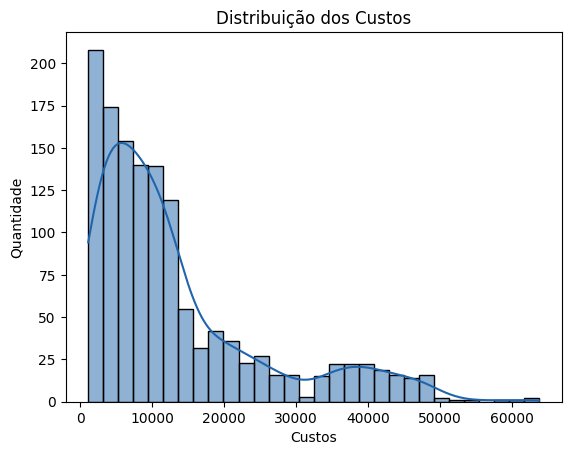

In [6]:
sns.histplot(df["charges"], kde=True, color= color_1)

plt.title("Distribuição dos Custos")
plt.xlabel("Custos")
plt.ylabel("Quantidade")
plt.show()

### Relação idade vs custo

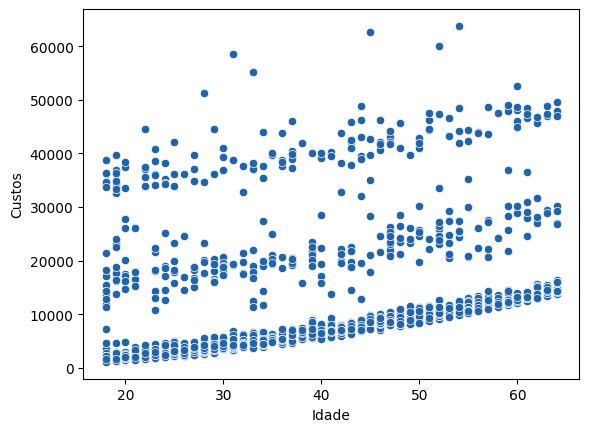

In [7]:
sns.scatterplot(data=df, x="age", y="charges",
                color = color_1)
plt.xlabel("Idade")
plt.ylabel("Custos")
plt.show()

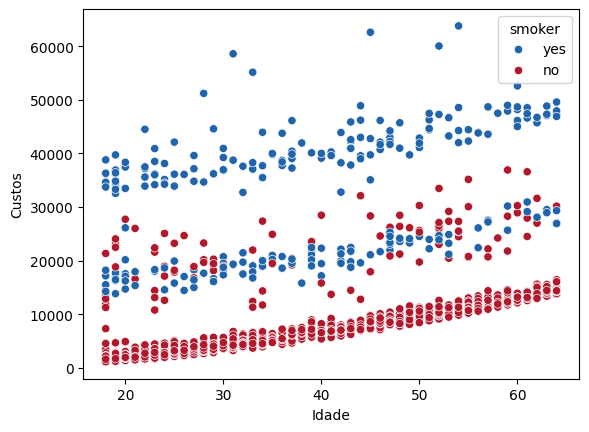

In [8]:
sns.scatterplot(data=df, x="age", y="charges",
                hue="smoker",
                palette = colors_disc)
plt.xlabel("Idade")
plt.ylabel("Custos")
plt.show()

### Boxplot fumante

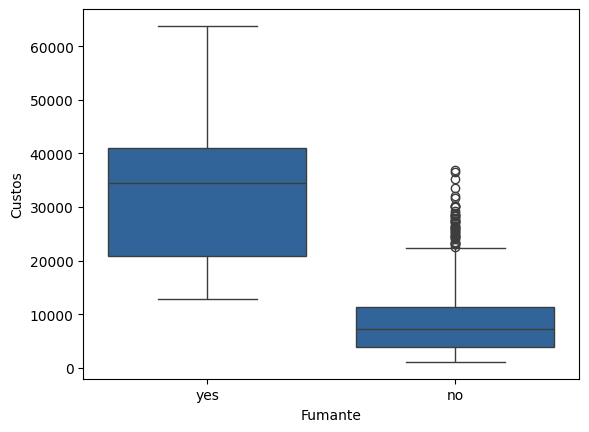

In [9]:
sns.boxplot(data=df, x="smoker", y="charges",
            color= color_1)
plt.xlabel("Fumante")
plt.ylabel("Custos")
plt.show()

### Correlação

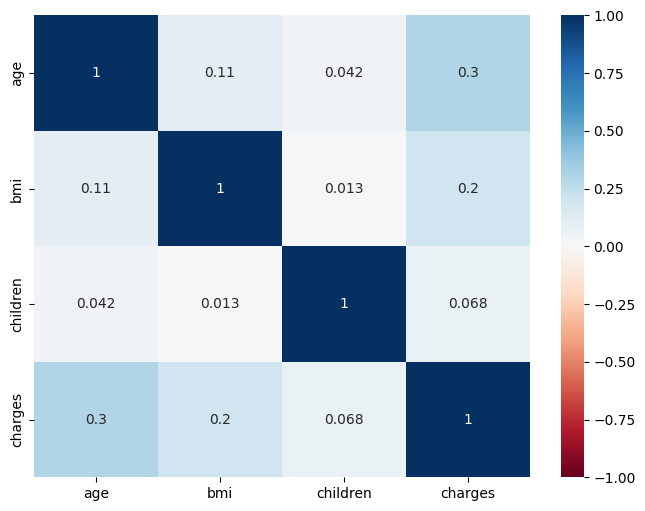

In [10]:
corr = df.corr(numeric_only=True)

# Colormap divergente padrão (azul/vermelho), com escala fixa de -1 a 1
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=-1, vmax=1, center=0)
plt.show()

### Análise exploratória (Pair Plot)

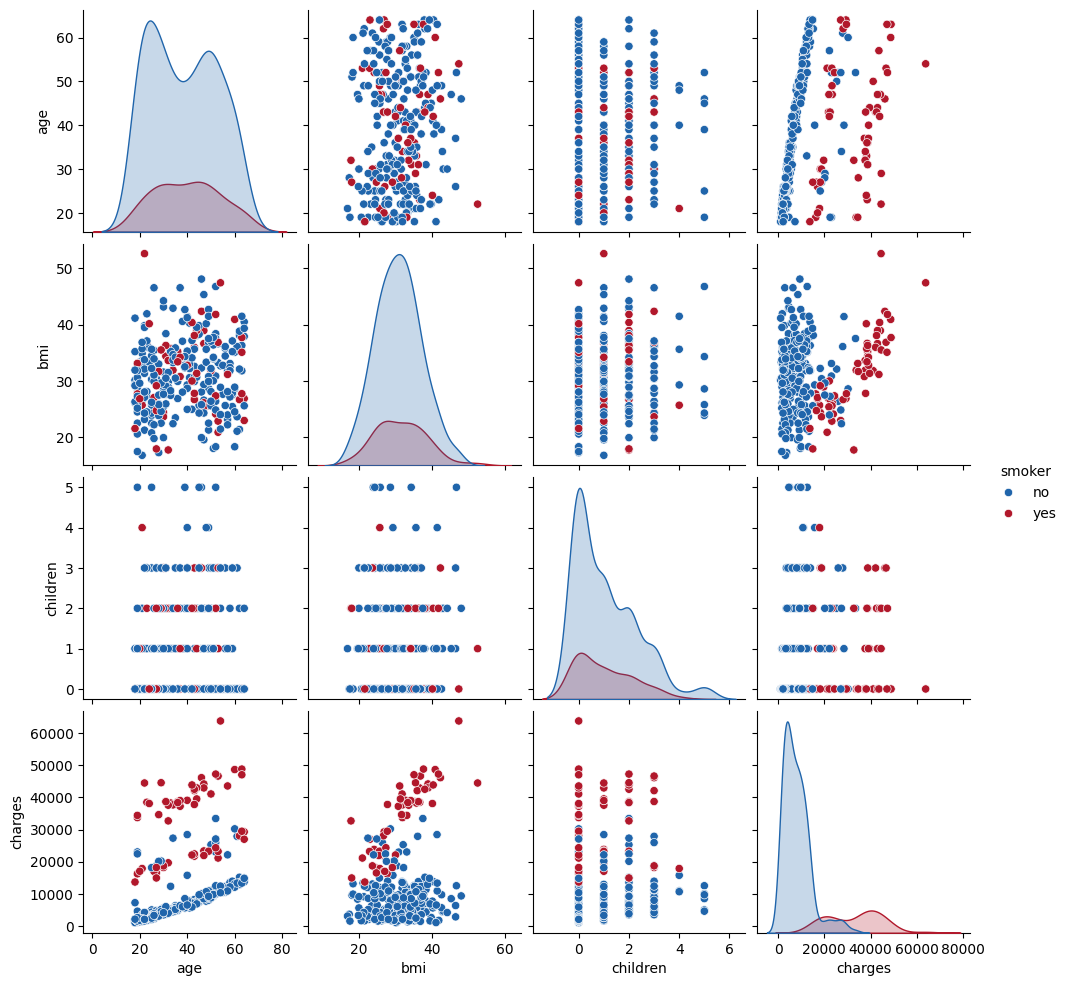

In [11]:
# Usamos uma amostra de 300 linhas: com as 1338 linhas completas o gráfico fica poluído e lento
df_sample = df.sample(300, random_state=42)

sns.pairplot(
    df_sample,
    hue="smoker",   # cor por fumante (muito didático)
    diag_kind="kde",
    palette = colors_disc
)

plt.show()

# 5. Preparação dos dados

### 5.1 Transformar as variáveis categóricas em numéricas

#### Por que a ordem importa: a armadilha da variável dummy

Antes de codificar "pra valer", vamos ver o que acontece se criarmos uma coluna dummy para **cada** categoria, sem descartar nenhuma.

In [12]:
df_sem_drop = pd.get_dummies(df, drop_first=False)
df_sem_drop.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


Repare que `sex_female` e `sex_male` são sempre complementares (uma é sempre `1 - a outra`), e o mesmo vale para `smoker_no`/`smoker_yes`. Cada par carrega exatamente a mesma informação duas vezes — isso é a **armadilha da variável dummy**, e causa multicolinearidade perfeita. Vamos treinar um modelo rápido só para ver o efeito disso nos coeficientes.

In [13]:
X_ilustracao = df_sem_drop.drop("charges", axis=1)
y_ilustracao = df_sem_drop["charges"]

modelo_ilustracao = LinearRegression()
modelo_ilustracao.fit(X_ilustracao, y_ilustracao)

coef_ilustracao = pd.DataFrame({
    "Variável": X_ilustracao.columns,
    "Coeficiente": modelo_ilustracao.coef_
}).sort_values(by="Coeficiente", ascending=False)

coef_ilustracao

,Variável,Coeficiente
6,smoker_yes,11924.267271
7,region_northeast,587.009235
2,children,475.500545
1,bmi,339.193454
0,age,256.856353
8,region_northwest,234.045336
3,sex_female,65.657180
4,sex_male,-65.657180
10,region_southwest,-373.041756
9,region_southeast,-448.012814


Veja os pares `sex_female`/`sex_male` e `smoker_yes`/`smoker_no`: são exatamente o mesmo valor, com sinal invertido. O modelo não consegue distinguir "o efeito de ser mulher" de "o efeito de não ser homem" — é a mesma informação repetida. A predição final ainda funciona, mas os coeficientes individuais perdem significado — péssimo justamente para o objetivo desta aula de **interpretar os coeficientes**.

### Corrigindo com drop_first

A solução é descartar uma categoria de cada variável como referência: seu efeito não desaparece, fica embutido no intercepto do modelo (o mesmo princípio do `drop='first'` que usamos com `OneHotEncoder` na aula sobre variáveis categóricas).

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### 5.2 Separar as variáveis independentes e dependentes (X e y)

In [15]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

### 5.3 Separar em dados de treino e teste

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Modelo de Regressão Linear

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

6.1 Resultados da Regressão

In [18]:
model.intercept_

np.float64(-11931.21905032666)

In [19]:
model.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

Repare que o coeficiente de `smoker_yes` aqui é bem maior do que na ilustração anterior — isso porque agora ele representa o efeito **completo** de ser fumante em relação à referência (`smoker_no`), em vez de estar artificialmente dividido pela metade entre duas colunas redundantes.

# 7. Avaliação

In [20]:
y_pred = model.predict(X_test)

print("R2 treino:", model.score(X_train, y_train))
print("R2 teste: ", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 treino: 0.7417255854683333
R2 teste:  0.7835929767120724
MAE: 4181.19447375365


O $R^2$ de teste ficou levemente **maior** que o de treino. Isso pode parecer estranho à primeira vista, mas não é sinal de erro: com uma divisão de dados (treino/teste) diferente a cada `random_state`, é normal que o subconjunto de teste, por variação amostral, seja um pouco mais fácil de prever do que o de treino. O importante é que os dois valores estão próximos — não há sinal de overfitting.

### 7.1 Coeficientes

In [21]:
coef = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": model.coef_
}).sort_values(by="Coeficiente", ascending=False)

coef

,Variável,Coeficiente
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


Agora não há mais pares espelhados — cada coeficiente carrega uma informação única e pode ser interpretado isoladamente.

### 7.2 Real vs Previsto

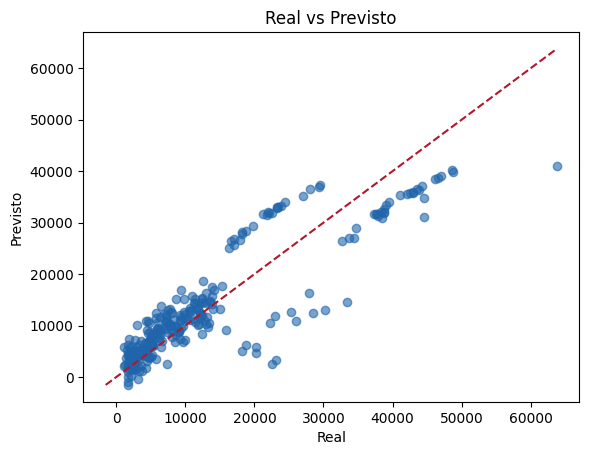

In [22]:
plt.scatter(y_test, y_pred, alpha=0.6, color = color_1)

# linha x = y
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())

plt.plot([min_val, max_val], [min_val, max_val], color= color_2, linestyle='--')

plt.xlabel("Real")
plt.ylabel("Previsto")
plt.title("Real vs Previsto")
plt.show()

### 7.3 Gráfico interativo

In [23]:
fig = px.scatter(
    x=y_test,
    y=y_pred,
    labels={"x": "Real", "y": "Previsto"},
    color_discrete_sequence=[color_1]
)

# Linha de referência (y = x)
fig.add_shape(
    type="line",
    x0=min(y_test),
    y0=min(y_test),
    x1=max(y_test),
    y1=max(y_test),
    line=dict(color=color_2, width=3)
)

fig.update_layout(
    title="Real vs Previsto",
    template="simple_white"
)

fig.show()

### 7.4 Análise de Resíduos

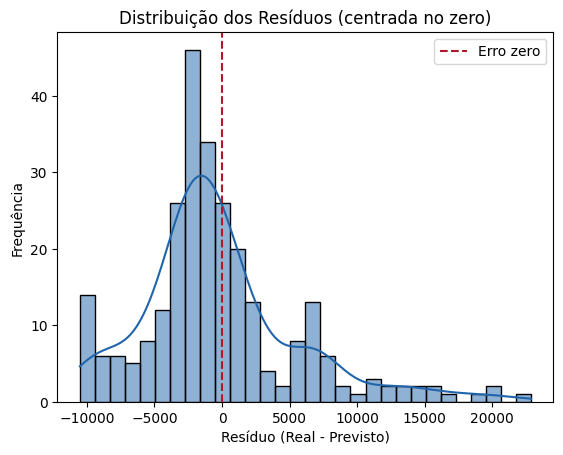

In [24]:
residuals = y_test - y_pred

sns.histplot(residuals, bins=30, kde=True, color = color_1)

plt.axvline(0, color=color_2, linestyle='--', label='Erro zero')

plt.title("Distribuição dos Resíduos (centrada no zero)")
plt.xlabel("Resíduo (Real - Previsto)")
plt.ylabel("Frequência")

plt.legend()
plt.show()

### Interpretação

* positivos → subestimamos custo
* negativos → superestimamos custo

# 8. Previsão de novos perfis

### Baixo Risco

In [25]:
perfil1 = pd.DataFrame({
    'age': [25],
    'bmi': [22],
    'children': [0],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

perfil1 = perfil1[X.columns]
custo1 = model.predict(perfil1)[0]

print(f" O Custo estimado do Perfil 1 é de : {custo1:.2f}")

 O Custo estimado do Perfil 1 é de : 1232.75


### Alto Risco

In [26]:
perfil2 = pd.DataFrame({
    'age': [55],
    'bmi': [32],
    'children': [2],
    'sex_male': [0],
    'smoker_yes': [1],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

perfil2 = perfil2[X.columns]
custo2 = model.predict(perfil2)[0]

print(f" O Custo estimado do Perfil 2 é de : {custo2:.2f}")

 O Custo estimado do Perfil 2 é de : 36833.23


# 9. Conclusões

## Insights principais

- Fumantes apresentam custo significativamente maior
- Idade tem impacto linear relevante
- Modelo consegue capturar boa parte da variabilidade
- Evitar colunas dummy redundantes (`drop_first`) garante que os coeficientes sejam interpretáveis individualmente, sem prejudicar a qualidade da predição

## Aplicações

- Segmentação de risco
- Programas de prevenção
- Precificação

## Fique Conectado

- [![YouTube](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/youtube_icon_color.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/linkedin_icon_color.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/instagram_icon_color.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!

_______

## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>


## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 04-04-2026       | 1.0     | Eduardo Pecora    | Estrutura de Aula               |
| 01-09-2026       | 1.1     | Eduardo Pecora | Incluido problemas dos Dummies, drop_first |

<hr>

## <h3 align="center"> (c) LDS / UFPR 2026. All rights reserved. <h3/>